# Question 2 - Dimension Reduction using Autoencoder

## Dataset: Stadium (Overhead-MNIST)

Dataset yang digunakan pada penelitian ini adalah kelas **Stadium** dari dataset **Overhead-MNIST**. Dataset ini berisi gambar objek yang diambil dari sudut pandang udara (overhead imagery) dengan ukuran gambar 28×28 piksel grayscale.

Sesuai instruksi soal, tujuan penelitian ini bukan untuk melakukan klasifikasi gambar, melainkan melakukan **dimension reduction** menggunakan arsitektur **Autoencoder**.

Dimension reduction dilakukan dengan mengompresi gambar dari dimensi awal:

- 28 × 28 = 784 fitur

menjadi representasi laten (latent representation) berdimensi:

- 128 fitur

Representasi laten tersebut kemudian digunakan oleh decoder untuk merekonstruksi kembali gambar ke ukuran semula sehingga kualitas hasil rekonstruksi dapat dievaluasi.

Tahapan penelitian yang dilakukan meliputi:

- Loading dataset Stadium
- Normalisasi (scaling) piksel ke rentang 0–1
- Menampilkan contoh gambar dataset
- Membagi dataset menjadi:
  - 80% Training Set
  - 10% Validation Set
  - 10% Test Set
- Membangun arsitektur baseline Autoencoder sesuai spesifikasi soal
- Melatih model Autoencoder menggunakan data training
- Merekonstruksi gambar pada data test
- Mengevaluasi kualitas hasil rekonstruksi menggunakan Structural Similarity Index (SSIM)

Structural Similarity Index (SSIM) digunakan untuk mengukur tingkat kemiripan antara gambar asli dan gambar hasil rekonstruksi. Nilai SSIM berada pada rentang 0 hingga 1, dimana nilai yang semakin mendekati 1 menunjukkan bahwa gambar hasil rekonstruksi semakin mirip dengan gambar asli.

Pada tahap selanjutnya, arsitektur Autoencoder akan dimodifikasi dan dilakukan tuning hyperparameter untuk memperoleh representasi dimensi yang lebih optimal serta meningkatkan kualitas rekonstruksi gambar berdasarkan nilai SSIM yang diperoleh.

# 2a. Loading, Scaling, dan Data Split

In [3]:
# Import Libraries

import os
import glob
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, Model

from skimage.metrics import structural_similarity as ssim

In [5]:
# Load Gambar Stadium
stadium_train = glob.glob(
    "version2/train/stadium/*.jpg"
)

stadium_test = glob.glob(
    "version2/test/stadium/*.jpg"
)

all_stadium = stadium_train + stadium_test

print("Total Images :", len(all_stadium))

Total Images : 7596


In [6]:
# Resize and Scaling
images = []

for img_path in all_stadium:
    img = Image.open(img_path).convert('L')
    img = np.array(img)

    images.append(img)

images = np.array(images)

print(images.shape)

(7596, 28, 28)


In [7]:
images = images.astype("float32") / 255.0

In [8]:
# Tambahkan Channel
images = np.expand_dims(images, axis=-1)

print(images.shape)

(7596, 28, 28, 1)


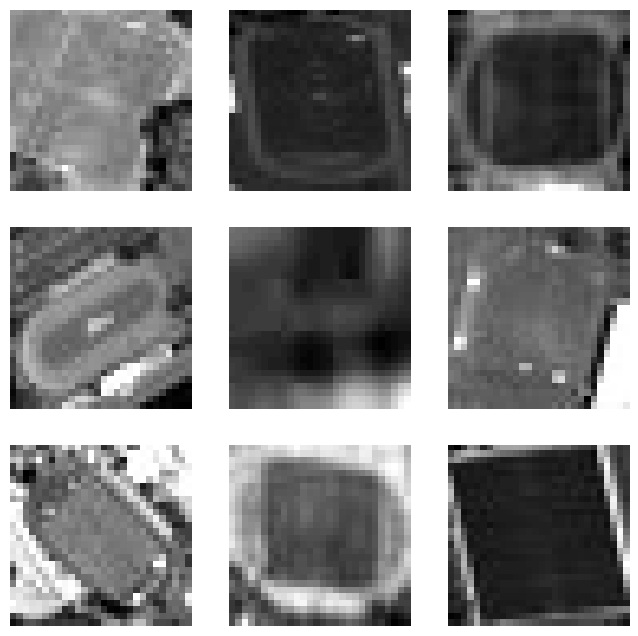

In [9]:
# Tampilan Contoh Data
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.show()

Split 80/10/10
Train 80%
Validation 10%
Test 10%

In [10]:
X_train, X_temp = train_test_split(
    images,
    test_size=0.20,
    random_state=42
)

X_val, X_test = train_test_split(
    X_temp,
    test_size=0.50,
    random_state=42
)

print("Train :", X_train.shape)
print("Val   :", X_val.shape)
print("Test  :", X_test.shape)

Train : (6076, 28, 28, 1)
Val   : (760, 28, 28, 1)
Test  : (760, 28, 28, 1)


## Data Spliting

Dataset Stadium yang digunakan terdiri dari 7.596 gambar grayscale berukuran 28×28 piksel.

Sebelum proses pelatihan, seluruh gambar dinormalisasi ke rentang nilai 0–1 dengan cara membagi setiap piksel dengan 255. Normalisasi dilakukan untuk mempercepat proses pembelajaran model dan meningkatkan stabilitas training.

Selanjutnya dataset dibagi menjadi tiga bagian dengan proporsi:

- Data Training : 6.076 gambar (80%)
- Data Validation : 760 gambar (10%)
- Data Testing : 760 gambar (10%)

Data training digunakan untuk melatih model Autoencoder, data validation digunakan untuk memantau performa model selama proses training, sedangkan data testing digunakan untuk evaluasi akhir menggunakan metrik Structural Similarity Index (SSIM).

In [11]:
print(X_train.min(), X_train.max())

0.0 1.0


# 2b Baseline Autoencoder

In [ ]:
# Encoder
input_img = layers.Input(shape=(28,28,1))

x = layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(input_img)

x = layers.MaxPooling2D(
    (2,2),
    padding='same'
)(x)

x = layers.Flatten()(x)

encoded = layers.Dense(
    128,
    activation='relu',
    name='latent_vector'
)(x)

In [13]:
# Decoder
x = layers.Dense(
    14*14*32,
    activation='relu'
)(encoded)

x = layers.Reshape((14,14,32))(x)

x = layers.UpSampling2D((2,2))(x)

decoded = layers.Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

In [14]:
# Build Model
autoencoder = Model(
    input_img,
    decoded
)

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,612,641 (6.15 MB)

 Trainable params: 1,612,641 (6.15 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Training
history = autoencoder.fit(
    X_train,
    X_train,
    validation_data=(X_val, X_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0190 - val_loss: 0.0092
Epoch 2/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0080 - val_loss: 0.0072
Epoch 3/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0066 - val_loss: 0.0061
Epoch 4/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0057 - val_loss: 0.0057
Epoch 5/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0052 - val_loss: 0.0051
Epoch 6/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0048 - val_loss: 0.0046
Epoch 7/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0045 - val_loss: 0.0045
Epoch 8/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0043 - val_loss: 0.0043
Epoch 9/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0041 - val_loss: 0.0041
Epoch 10/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 11/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0039 - val_loss: 0.0040
Epoch 12/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 

In [16]:
# Reconstruction
reconstructed = autoencoder.predict(X_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


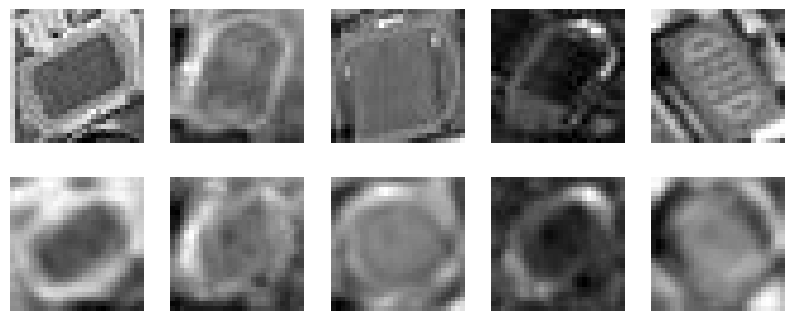

In [17]:
# visualisasi hasil decoder
n = 5

plt.figure(figsize=(10,4))

for i in range(n):

    plt.subplot(2,n,i+1)
    plt.imshow(
        X_test[i].squeeze(),
        cmap='gray'
    )
    plt.axis('off')

    plt.subplot(2,n,i+n+1)
    plt.imshow(
        reconstructed[i].squeeze(),
        cmap='gray'
    )
    plt.axis('off')

plt.show()

In [18]:
ssim_scores = []

for i in range(len(X_test)):

    score = ssim(
        X_test[i].squeeze(),
        reconstructed[i].squeeze(),
        data_range=1.0
    )

    ssim_scores.append(score)

mean_ssim = np.mean(ssim_scores)

print("Average SSIM:", mean_ssim)

Average SSIM: 0.6946154647859414


## Evaluasi Baseline Autoencoder Menggunakan SSIM

Setelah model Autoencoder dilatih menggunakan dataset Stadium, dilakukan evaluasi terhadap kualitas gambar hasil rekonstruksi menggunakan metrik Structural Similarity Index (SSIM).

Hasil evaluasi menunjukkan bahwa model memperoleh nilai rata-rata SSIM sebesar **0.6946** pada data test.

Nilai SSIM berada pada rentang 0 hingga 1, dimana nilai yang semakin mendekati 1 menunjukkan bahwa gambar hasil rekonstruksi semakin mirip dengan gambar asli.

Nilai SSIM sebesar 0.6946 menunjukkan bahwa Autoencoder baseline telah mampu mempelajari pola utama dari gambar stadium dan merekonstruksi kembali sebagian besar struktur visual yang terdapat pada gambar asli. Namun demikian, masih terdapat kehilangan informasi pada beberapa detail gambar sehingga hasil rekonstruksi belum sepenuhnya identik dengan gambar masukan.

Hasil ini akan digunakan sebagai baseline untuk dibandingkan dengan arsitektur Autoencoder yang telah dimodifikasi pada tahap berikutnya.

## Kesimpulan Baseline Autoencoder

Autoencoder baseline berhasil melakukan proses dimension reduction dari 784 dimensi (28×28 piksel) menjadi representasi laten berukuran 128 dimensi.

Model mampu menghasilkan gambar rekonstruksi dengan nilai rata-rata SSIM sebesar 0.6946. Hasil ini menunjukkan bahwa model telah mampu mempertahankan sebagian besar informasi penting dari gambar asli, namun masih terdapat ruang untuk peningkatan performa melalui modifikasi arsitektur dan tuning hyperparameter.

Pada tahap berikutnya akan dilakukan pengembangan arsitektur Autoencoder untuk memperoleh nilai SSIM yang lebih tinggi dan representasi fitur yang lebih optimal.

# 2c. Modifikasi Arsitektur Autoencoder dan Hyperparameter Tuning

Pada tahap sebelumnya, Autoencoder baseline menghasilkan nilai rata-rata Structural Similarity Index (SSIM) sebesar **0.6946** pada data test. Meskipun model telah mampu merekonstruksi gambar dengan cukup baik, masih terdapat kehilangan informasi pada beberapa bagian gambar sehingga kualitas rekonstruksi belum optimal.

Untuk meningkatkan kualitas representasi fitur dan hasil rekonstruksi gambar, dilakukan modifikasi arsitektur Autoencoder dengan menambahkan beberapa komponen yang umum digunakan dalam Convolutional Neural Network (CNN).

Modifikasi yang dilakukan meliputi:

1. Menambahkan layer Convolutional dengan jumlah filter yang lebih banyak.
2. Menambahkan Batch Normalization untuk menstabilkan proses pembelajaran.
3. Menambahkan Dropout untuk mengurangi risiko overfitting.
4. Memperdalam arsitektur encoder dan decoder agar mampu mempelajari fitur gambar yang lebih kompleks.
5. Melakukan tuning hyperparameter seperti jumlah epoch, batch size, dan learning rate.

Tujuan dari modifikasi ini adalah menghasilkan representasi laten yang lebih informatif sehingga proses rekonstruksi gambar dapat mempertahankan lebih banyak informasi dari gambar asli.

In [31]:
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D,
    Flatten,
    Dense,
    Reshape,
    BatchNormalization,
    Dropout
)

from tensorflow.keras.models import Model

input_img = Input(shape=(28,28,1))

# ==========================
# ENCODER
# ==========================

x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(input_img)

x = BatchNormalization()(x)

x = MaxPooling2D(
    (2,2),
    padding='same'
)(x)

x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

x = MaxPooling2D(
    (2,2),
    padding='same'
)(x)

x = Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

x = Flatten()(x)

x = Dropout(0.1)(x)

latent = Dense(
    128,
    activation='relu',
    name='latent_vector'
)(x)

# ==========================
# DECODER
# ==========================

x = Dense(
    7 * 7 * 128,
    activation='relu'
)(latent)

x = Reshape((7,7,128))(x)

x = Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = UpSampling2D((2,2))(x)

x = BatchNormalization()(x)

x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = UpSampling2D((2,2))(x)

x = BatchNormalization()(x)

x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(x)

decoded = Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

autoencoder_v2 = Model(
    input_img,
    decoded
)

autoencoder_v2.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,946,497 (7.43 MB)

 Trainable params: 1,945,665 (7.42 MB)

 Non-trainable params: 832 (3.25 KB)

In [32]:
#compile model
from tensorflow.keras.optimizers import Adam

autoencoder_v2.compile(
    optimizer=Adam(
        learning_rate=0.0001
    ),
    loss='mse'
)

In [33]:
#Early Stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [34]:
#Training
history_v2 = autoencoder_v2.fit(
    X_train,
    X_train,
    validation_data=(X_val, X_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 13s 88ms/step - loss: 0.0163 - val_loss: 0.0544
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0099 - val_loss: 0.0589
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - loss: 0.0084 - val_loss: 0.0584
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - loss: 0.0077 - val_loss: 0.0376
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - loss: 0.0068 - val_loss: 0.0210
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - loss: 0.0066 - val_loss: 0.0115
Epoch 7/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - loss: 0.0064 - val_loss: 0.0063
Epoch 8/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 14s 132ms/step - loss: 0.0060 - val_loss: 0.0052
Epoch 9/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - loss: 0.0057 - val_loss: 0.0051
Epoch 10/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - loss: 0.0055 - val_loss: 0.0055
Epoch 11/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - loss: 0.0053 - val_loss: 0.0048
Epoch 12/100
95/95 ━━━━━━━━━━━━━━

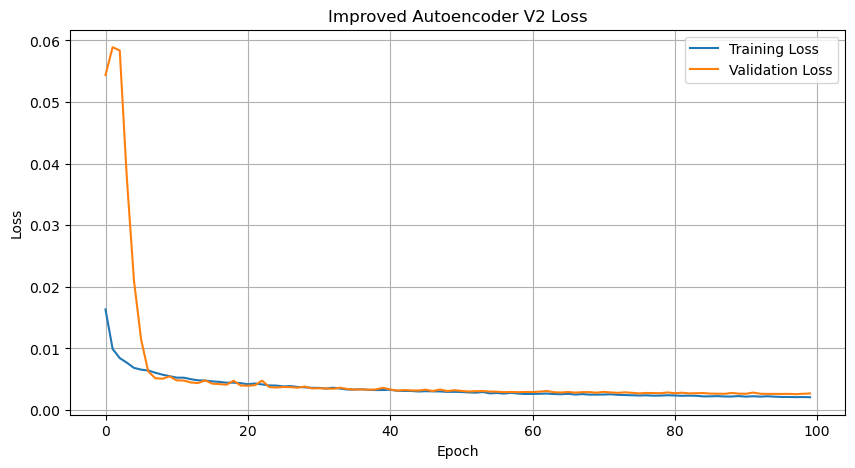

In [37]:
# visualisasi Loss training
plt.figure(figsize=(10,5))

plt.plot(
    history_v2.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_v2.history['val_loss'],
    label='Validation Loss'
)

plt.title('Improved Autoencoder V2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

### Improved Model Training Analysis

Berdasarkan grafik training history, nilai **training loss** mengalami penurunan yang sangat cepat pada awal proses pelatihan, kemudian terus menurun secara bertahap hingga mencapai kondisi yang stabil pada akhir training. Hal ini menunjukkan bahwa model berhasil mempelajari representasi fitur citra stadium secara efektif.

Nilai **validation loss** pada awal training sempat lebih tinggi dibandingkan training loss, namun mengalami penurunan yang sangat signifikan hanya dalam beberapa epoch pertama. Setelah itu, validation loss bergerak sangat dekat dengan training loss dan tetap stabil hingga proses pelatihan selesai.

Perbedaan antara training loss dan validation loss sangat kecil setelah model mencapai kondisi stabil. Hal ini menunjukkan bahwa model memiliki kemampuan **generalisasi** yang baik dan tidak menunjukkan indikasi **overfitting** yang signifikan terhadap data validasi.

Selain itu, kedua kurva menunjukkan pola konvergensi yang baik tanpa fluktuasi yang berlebihan pada epoch-epoch akhir. Kondisi ini mengindikasikan bahwa proses optimasi berlangsung secara stabil dan model telah mencapai solusi yang optimal sebelum digunakan pada tahap evaluasi.

Secara keseluruhan, hasil training menunjukkan bahwa **Improved Autoencoder V2** mampu mempelajari karakteristik citra pada dataset **Stadium** dengan sangat baik. Stabilitas training dan validation loss menunjukkan bahwa modifikasi arsitektur berhasil meningkatkan kualitas proses pembelajaran sehingga model layak digunakan untuk tahap evaluasi menggunakan metrik **Structural Similarity Index Measure (SSIM)**.

In [35]:
#Prediksi Hasil Rekonstruksi
reconstructed_v2 = autoencoder_v2.predict(X_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


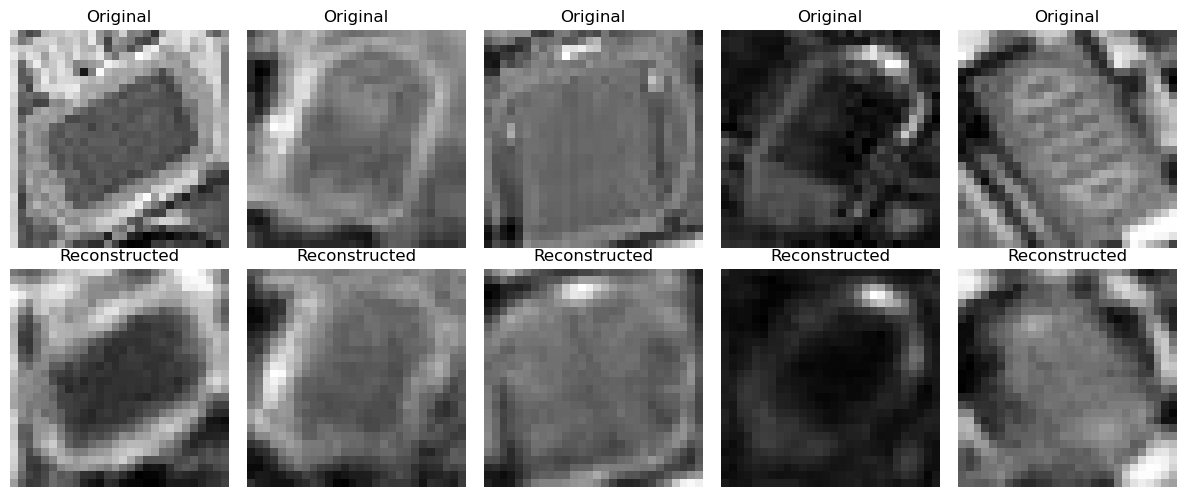

In [40]:
# visualisasi original vs reconstruction
n = 5

plt.figure(figsize=(12,5))

for i in range(n):

    # Original
    plt.subplot(2,n,i+1)
    plt.imshow(
        X_test[i].squeeze(),
        cmap='gray'
    )
    plt.title("Original")
    plt.axis('off')

    # Reconstruction
    plt.subplot(2,n,i+n+1)
    plt.imshow(
        reconstructed_v2[i].squeeze(),
        cmap='gray'
    )
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [41]:
#hitung SSIM
from skimage.metrics import structural_similarity as ssim

ssim_scores_v2 = []

for i in range(len(X_test)):

    score = ssim(
        X_test[i].squeeze(),
        reconstructed_v2[i].squeeze(),
        data_range=1.0
    )

    ssim_scores_v2.append(score)

average_ssim_v2 = np.mean(
    ssim_scores_v2
)

print(
    "Average SSIM V2:",
    average_ssim_v2
)

Average SSIM V2: 0.7740348177803116


In [42]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Baseline Autoencoder",
        "Improved Autoencoder"
    ],
    "SSIM": [
        0.6946154647859414,
        average_ssim_v2
    ]
})

comparison

,Model,SSIM
0,Baseline Autoencoder,0.694615
1,Improved Autoencoder,0.774035


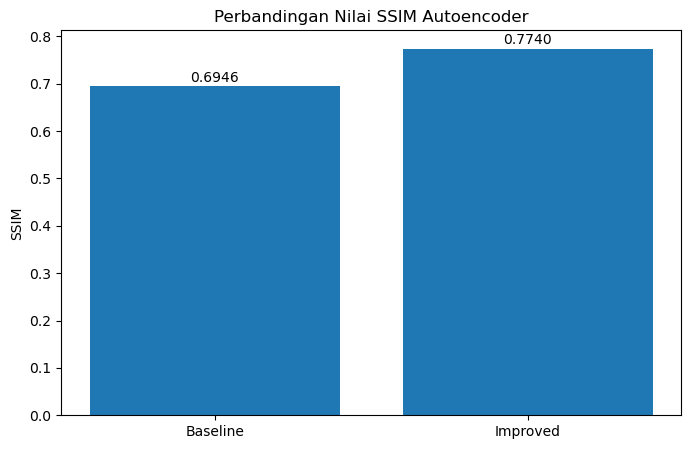

In [43]:
models = [
    "Baseline",
    "Improved"
]

scores = [
    0.6946154647859414,
    average_ssim_v2
]

plt.figure(figsize=(8,5))

plt.bar(models, scores)

plt.ylabel("SSIM")
plt.title("Perbandingan Nilai SSIM Autoencoder")

for i, v in enumerate(scores):
    plt.text(
        i,
        v + 0.01,
        f"{v:.4f}",
        ha='center'
    )

plt.show()

## Evaluasi Autoencoder yang Dimodifikasi

Setelah dilakukan modifikasi arsitektur Autoencoder dan tuning hyperparameter, diperoleh nilai rata-rata Structural Similarity Index (SSIM) sebesar **0.7740** pada data test.

Jika dibandingkan dengan model baseline yang memperoleh nilai SSIM sebesar **0.6946**, model yang dimodifikasi menunjukkan peningkatan performa sebesar **0.0794** atau sekitar **11.43%**.

Peningkatan ini menunjukkan bahwa model yang dimodifikasi mampu menghasilkan gambar rekonstruksi yang lebih mirip dengan gambar asli dibandingkan model baseline.

Beberapa faktor yang berkontribusi terhadap peningkatan performa antara lain:

1. Penambahan layer konvolusi dengan jumlah filter yang lebih banyak sehingga model mampu mempelajari fitur visual yang lebih kompleks.
2. Penggunaan Batch Normalization yang membantu menstabilkan proses training dan mempercepat konvergensi model.
3. Penggunaan Dropout untuk mengurangi risiko overfitting.
4. Tuning hyperparameter seperti learning rate, jumlah epoch, dan Early Stopping yang menghasilkan proses pembelajaran yang lebih optimal.

Berdasarkan hasil tersebut, dapat disimpulkan bahwa arsitektur Autoencoder yang dimodifikasi mampu menghasilkan representasi laten yang lebih baik dibandingkan model baseline.

## Kesimpulan

Pada penelitian ini dilakukan proses dimension reduction menggunakan Autoencoder pada dataset Stadium dari Overhead-MNIST.

Model baseline berhasil melakukan kompresi gambar dari dimensi 784 menjadi representasi laten berukuran 128 dimensi dengan nilai SSIM sebesar **0.6946**.

Selanjutnya dilakukan modifikasi arsitektur dan tuning hyperparameter untuk meningkatkan kualitas rekonstruksi gambar. Model yang dimodifikasi berhasil meningkatkan nilai SSIM menjadi **0.7740**.

Hasil tersebut menunjukkan bahwa model yang dimodifikasi mampu mempertahankan lebih banyak informasi visual dari gambar asli sehingga menghasilkan kualitas rekonstruksi yang lebih baik dibandingkan model baseline.

Dengan demikian, Autoencoder yang dimodifikasi dapat dianggap sebagai model terbaik untuk melakukan dimension reduction pada dataset Stadium.